In [2]:
%%capture
from typing import Annotated
from dotenv import load_dotenv
load_dotenv() #we nned our gemmini key

from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
llm = init_chat_model("google_genai:gemini-2.0-flash")

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
def chatbot(state: State) -> State:
    '''
    A simple chatbot that uses a language model to respond to messages.
    Args:
        state (State): The current state of the graph which containing messages.
    Returns:
        State: The updated state with the model's response added to messages.
    '''
    
    return {
        "messages": [llm.invoke(state["messages"])]
    }

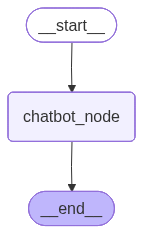

In [6]:
builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [7]:
message = {
    "role": "user", 
    "content": "Who walked on the moon for the first time? Print only the name"
    }

response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='f553fd3e-e1e0-4427-9a5b-836dc3008471'),
 AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b0ed3-015c-7a72-82ee-44d58e26084a-0', usage_metadata={'input_tokens': 14, 'output_tokens': 3, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}})]

In [9]:
message = {
    "role": "user", 
    "content": "Can you show me the Sherlock Homes home address? Print only the address."
    }

response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Can you show me the Sherlock Homes home address? Print only the address.', additional_kwargs={}, response_metadata={}, id='8a8c76c0-8730-4600-b817-df4b657b6b5b'),
 AIMessage(content='221B Baker Street, London', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b0ed4-24d2-7832-b458-5b42c74945de-0', usage_metadata={'input_tokens': 15, 'output_tokens': 9, 'total_tokens': 24, 'input_token_details': {'cache_read': 0}})]

Simple chat bot craeation for retrieving a session without long-term memory

In [11]:
state = None

while True:
    in_message = input("please enter your new prompt: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if state is None:
        state: State = {
            "messages": [
                {
                    "role": "user", 
                    "content": in_message
                }
            ]
        }
    else:
        state["messages"].append(
            {
                "role": "user",
                "content": in_message
            })

    state = graph.invoke(state)

    print(
        "Bot:", state["messages"][-1].content)

Bot: The capital of France is **Paris**.
Bot: The capital of Iran is **Tehran**.
Bot: The Prague Spring movement happened in Czechoslovakia in **1968**.
Bot: Pinpointing a single "victory date" for the French Revolution is tricky because it was a complex and multifaceted process with many turning points. However, here are some significant dates that could be considered milestones:

*   **July 14, 1789 - Storming of the Bastille:** This event is widely considered the symbolic start of the French Revolution. It demonstrated popular uprising against royal authority.

*   **August 26, 1789 - Declaration of the Rights of Man and of the Citizen:** This document established fundamental rights and freedoms, marking a significant victory for Enlightenment ideals.

*   **September 21, 1792 - Abolition of the Monarchy:** The National Convention declared France a republic, formally ending the reign of the monarchy. This could be considered a major turning point.

*   **November 9, 1799 - The Coup 